# 🔭 GitHub Scout — Repository Intelligence Analysis

Interactive analytics notebook for exploring crawled GitHub repository data,
scoring distributions, and trend analysis.

---

## 0. Setup & Connection

In [1]:
import os
from pathlib import Path
from datetime import datetime, timezone

import duckdb
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dotenv import load_dotenv

# Load environment
load_dotenv(dotenv_path=Path("../.env"))
DB_PATH = os.getenv("DB_PATH", "../github_scout.duckdb")

con = duckdb.connect(str(DB_PATH), read_only=True)
print(f"✅ Connected to: {DB_PATH}")


def sql(query: str) -> pl.DataFrame:
    """Execute a SQL query and return results as a Polars DataFrame."""
    return con.execute(query).pl()


# Schema info
tables = sql("SELECT table_name FROM information_schema.tables WHERE table_schema = 'main'")
print(f"\n📋 Tables: {tables['table_name'].to_list()}")
for t in tables['table_name']:
    count = sql(f"SELECT COUNT(*) AS n FROM {t}")['n'][0]
    print(f"   {t}: {count:,} rows")

✅ Connected to: ../github_scout.duckdb

📋 Tables: ['crawl_runs', 'repositories', 'repo_snapshots']
   crawl_runs: 1 rows
   repositories: 555 rows
   repo_snapshots: 555 rows


## 1. Database Overview

In [2]:
overview = sql("""
SELECT
    COUNT(*) AS total_repos,
    COUNT(DISTINCT primary_language) AS languages,
    MIN(scraped_at) AS earliest_scrape,
    MAX(scraped_at) AS latest_scrape,
    ROUND(AVG(potential_score), 2) AS avg_score,
    ROUND(AVG(stars), 1) AS avg_stars,
    SUM(stars) AS total_stars
FROM repositories
""")
print("📊 Repository Overview")
print(overview)

snapshots_info = sql("""
SELECT
    COUNT(*) AS total_snapshots,
    COUNT(DISTINCT repo_id) AS repos_with_snapshots,
    MIN(snapshot_at) AS earliest,
    MAX(snapshot_at) AS latest
FROM repo_snapshots
""")
print("\n📸 Snapshots")
print(snapshots_info)

crawl_info = sql("""
SELECT
    run_id, status, repos_found, repos_new, repos_updated, errors_count,
    started_at, finished_at
FROM crawl_runs
ORDER BY started_at DESC
LIMIT 10
""")
print("\n🕷️ Recent Crawl Runs")
print(crawl_info)

📊 Repository Overview
shape: (1, 7)
┌─────────────┬───────────┬────────────────────────────────┬────────────────────────────────┬───────────┬───────────┬───────────────┐
│ total_repos ┆ languages ┆ earliest_scrape                ┆ latest_scrape                  ┆ avg_score ┆ avg_stars ┆ total_stars   │
│ ---         ┆ ---       ┆ ---                            ┆ ---                            ┆ ---       ┆ ---       ┆ ---           │
│ i64         ┆ i64       ┆ datetime[μs, Europe/Madrid]    ┆ datetime[μs, Europe/Madrid]    ┆ f64       ┆ f64       ┆ decimal[38,0] │
╞═════════════╪═══════════╪════════════════════════════════╪════════════════════════════════╪═══════════╪═══════════╪═══════════════╡
│ 555         ┆ 2         ┆ 2026-02-22 20:19:14.705848 CET ┆ 2026-02-22 20:20:56.713135 CET ┆ 34.39     ┆ 560.1     ┆ 310846        │
└─────────────┴───────────┴────────────────────────────────┴────────────────────────────────┴───────────┴───────────┴───────────────┘

📸 Snapshots
shape: (1, 4)

## 2. Score Distribution

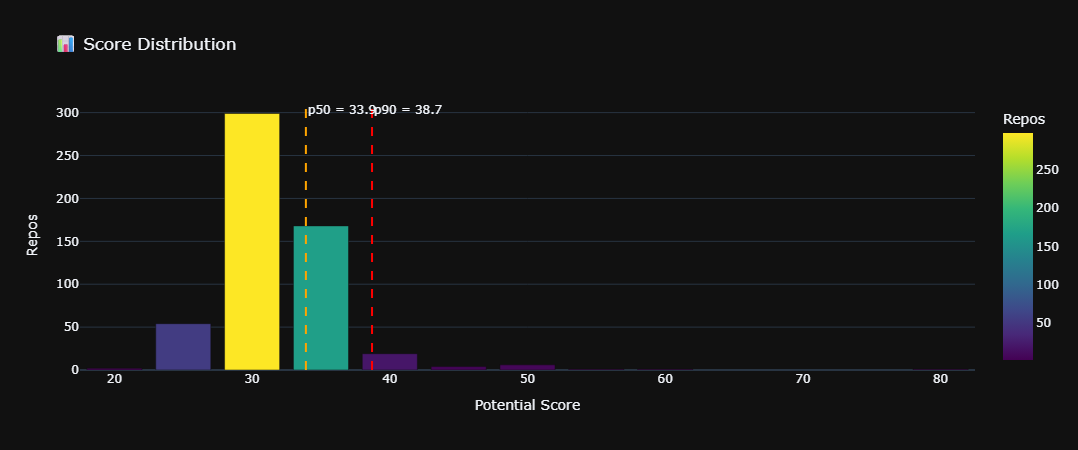

In [3]:
# DuckDB 1.4 compatible (no WIDTH_BUCKET)
score_dist = sql("""
SELECT
    CAST(FLOOR(potential_score / 5) AS INTEGER) AS bucket,
    COUNT(*) AS count,
    MIN(potential_score) AS bucket_min,
    MAX(potential_score) AS bucket_max
FROM repositories
WHERE potential_score IS NOT NULL
GROUP BY bucket
ORDER BY bucket
""")

# Percentiles for vertical lines
pcts = sql("""
SELECT
    PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY potential_score) AS p50,
    PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY potential_score) AS p90
FROM repositories
WHERE potential_score IS NOT NULL
""")
p50 = pcts['p50'][0]
p90 = pcts['p90'][0]

score_dist = score_dist.with_columns(
    (pl.col("bucket") * 5).alias("range_start")
)

fig = px.bar(
    score_dist.to_pandas(),
    x="range_start", y="count",
    labels={"range_start": "Potential Score", "count": "Repos"},
    title="📊 Score Distribution",
    color="count",
    color_continuous_scale="Viridis",
)
fig.add_vline(x=p50, line_dash="dash", line_color="orange",
              annotation_text=f"p50 = {p50:.1f}")
fig.add_vline(x=p90, line_dash="dash", line_color="red",
              annotation_text=f"p90 = {p90:.1f}")
fig.update_layout(template="plotly_dark", height=450)
fig.show()

## 3. Top 20 Repos by Potential Score

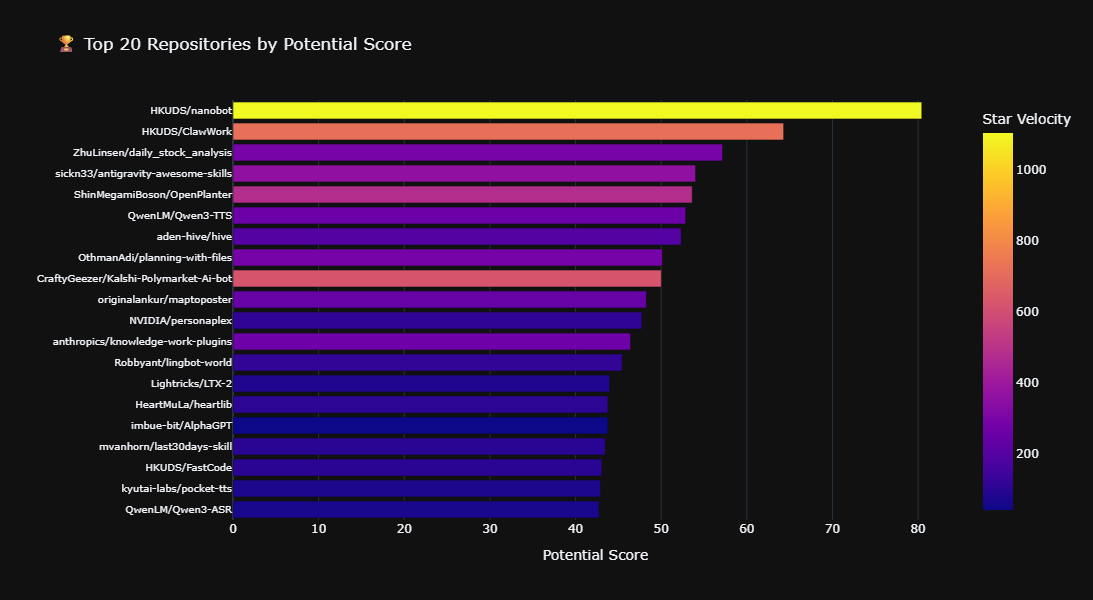

In [4]:
top20 = sql("""
SELECT
    full_name, potential_score, star_velocity, stars, forks,
    description, topics, created_at, primary_language
FROM repositories
WHERE potential_score IS NOT NULL
ORDER BY potential_score DESC
LIMIT 20
""")

top20_pd = top20.to_pandas()
top20_pd['topics_str'] = top20_pd['topics'].apply(
    lambda x: ', '.join(x) if isinstance(x, list) else str(x)
)

fig = px.bar(
    top20_pd.iloc[::-1],  # reverse for horizontal layout
    x="potential_score", y="full_name",
    orientation="h",
    color="star_velocity",
    color_continuous_scale="Plasma",
    hover_data=["description", "stars", "forks", "topics_str", "created_at"],
    title="🏆 Top 20 Repositories by Potential Score",
    labels={"potential_score": "Potential Score", "full_name": "",
            "star_velocity": "Star Velocity"},
)
fig.update_layout(template="plotly_dark", height=600, yaxis_tickfont_size=10)
fig.show()

## 4. Star Velocity Analysis

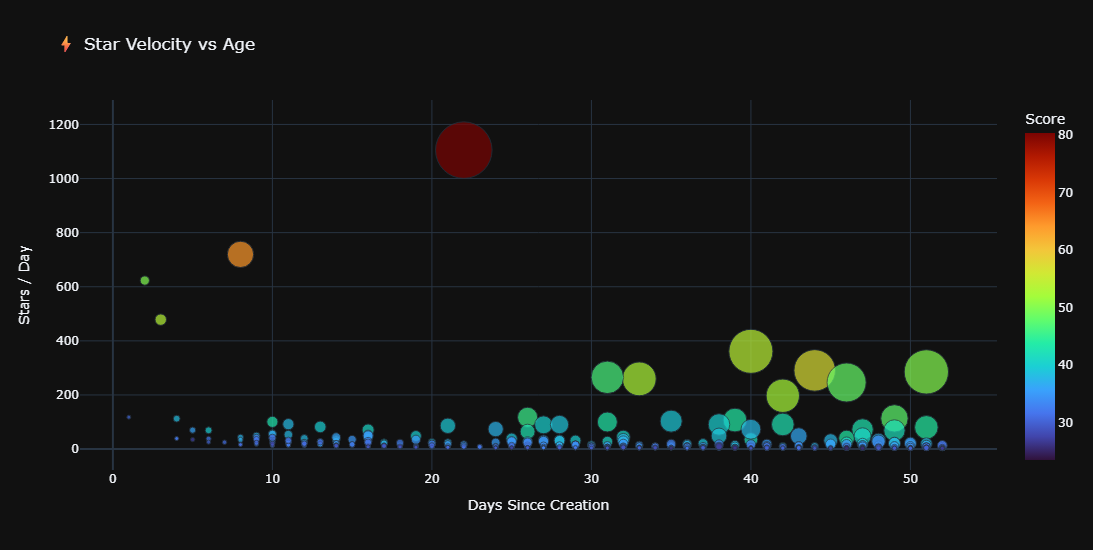

In [5]:
velocity = sql("""
SELECT
    full_name,
    stars,
    forks,
    potential_score,
    star_velocity,
    DATEDIFF('day', created_at, current_timestamp) AS days_since_creation,
    description
FROM repositories
WHERE star_velocity IS NOT NULL
ORDER BY potential_score DESC NULLS LAST
""")

vel_pd = velocity.to_pandas()

fig = px.scatter(
    vel_pd,
    x="days_since_creation", y="star_velocity",
    size="stars", color="potential_score",
    color_continuous_scale="Turbo",
    hover_name="full_name",
    hover_data=["description", "stars", "forks"],
    title="⚡ Star Velocity vs Age",
    labels={"days_since_creation": "Days Since Creation",
            "star_velocity": "Stars / Day",
            "potential_score": "Score"},
    size_max=40,
)
fig.update_layout(template="plotly_dark", height=550)
fig.show()

## 5. Topic Heatmap

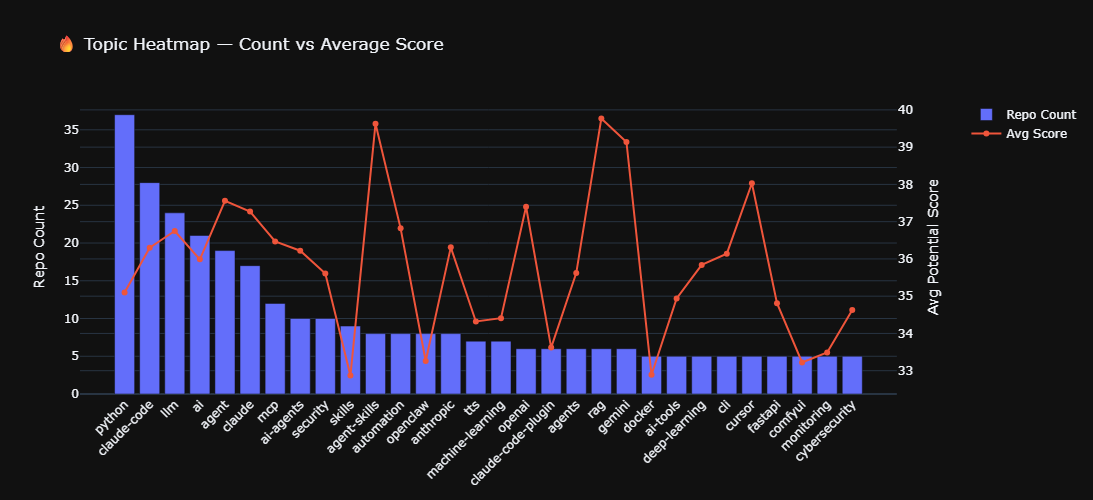

In [6]:
# DuckDB 1.4 compatible (CTE-based UNNEST)
topics = sql("""
WITH exploded AS (
    SELECT UNNEST(topics) AS topic, potential_score
    FROM repositories
    WHERE topics IS NOT NULL
)
SELECT
    topic,
    COUNT(*) AS repo_count,
    ROUND(AVG(potential_score), 2) AS avg_score
FROM exploded
GROUP BY topic
ORDER BY repo_count DESC
LIMIT 30
""")

topics_pd = topics.to_pandas()

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Bar(x=topics_pd['topic'], y=topics_pd['repo_count'],
           name='Repo Count', marker_color='#636EFA'),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=topics_pd['topic'], y=topics_pd['avg_score'],
               name='Avg Score', mode='lines+markers',
               marker_color='#EF553B', line_width=2),
    secondary_y=True,
)
fig.update_layout(
    title='🔥 Topic Heatmap — Count vs Average Score',
    template='plotly_dark', height=500,
    xaxis_tickangle=-45,
)
fig.update_yaxes(title_text='Repo Count', secondary_y=False)
fig.update_yaxes(title_text='Avg Potential Score', secondary_y=True)
fig.show()

## 6. 7-Day Momentum Trending

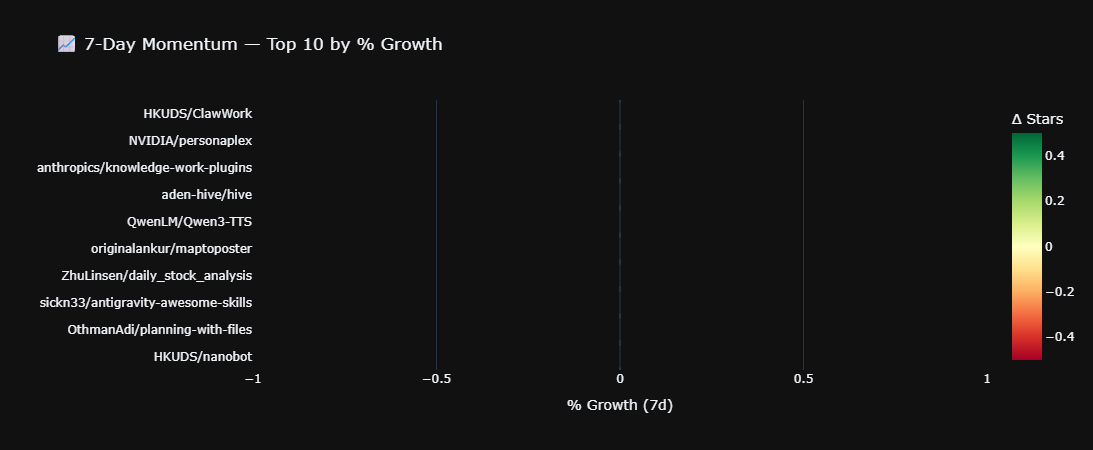

In [7]:
momentum = sql("""
WITH latest AS (
    SELECT repo_id, MAX(snapshot_at) AS max_snap
    FROM repo_snapshots GROUP BY repo_id
),
week_ago AS (
    SELECT repo_id, stars AS stars_7d
    FROM repo_snapshots
    WHERE snapshot_at >= current_timestamp - INTERVAL '7 days'
    QUALIFY ROW_NUMBER() OVER (PARTITION BY repo_id ORDER BY snapshot_at ASC) = 1
),
current_snap AS (
    SELECT s.repo_id, s.stars AS stars_now
    FROM repo_snapshots s JOIN latest l
        ON s.repo_id = l.repo_id AND s.snapshot_at = l.max_snap
)
SELECT
    r.full_name,
    cs.stars_now,
    wa.stars_7d,
    cs.stars_now - wa.stars_7d AS delta_stars,
    ROUND((cs.stars_now - wa.stars_7d) * 100.0 / GREATEST(wa.stars_7d, 1), 2) AS pct_growth_7d
FROM current_snap cs
JOIN week_ago wa ON cs.repo_id = wa.repo_id
JOIN repositories r ON r.id = cs.repo_id
ORDER BY pct_growth_7d DESC
LIMIT 10
""")

if momentum.height > 0:
    mom_pd = momentum.to_pandas()
    fig = px.bar(
        mom_pd,
        x='pct_growth_7d', y='full_name',
        orientation='h',
        color='delta_stars',
        color_continuous_scale='RdYlGn',
        hover_data=['stars_now', 'stars_7d', 'delta_stars'],
        title='📈 7-Day Momentum — Top 10 by % Growth',
        labels={'pct_growth_7d': '% Growth (7d)', 'full_name': '',
                'delta_stars': 'Δ Stars'},
    )
    fig.update_layout(template='plotly_dark', height=450)
    fig.show()
else:
    print('⚠️ Not enough snapshot data for 7-day momentum (need multiple crawls).')

## 7. Scoring Weight Experimentation

Adjust the sliders below to experiment with different scoring weights.
The top 20 repos will be recomputed in real time.

In [8]:
import ipywidgets as widgets
from IPython.display import display, clear_output

w_velocity = widgets.FloatSlider(value=0.35, min=0, max=1, step=0.05,
                                  description='star_velocity')
w_recency  = widgets.FloatSlider(value=0.20, min=0, max=1, step=0.05,
                                  description='recency')
w_activity = widgets.FloatSlider(value=0.20, min=0, max=1, step=0.05,
                                  description='activity')
w_momentum = widgets.FloatSlider(value=0.15, min=0, max=1, step=0.05,
                                  description='momentum_7d')
w_readme   = widgets.FloatSlider(value=0.10, min=0, max=1, step=0.05,
                                  description='readme')

output = widgets.Output()


def _minmax(s: pl.Series) -> pl.Series:
    """Min-max normalise a Series to [0, 1]."""
    mn, mx = s.min(), s.max()
    rng = mx - mn if (mx - mn) > 1e-9 else 1e-9
    return (s - mn) / rng


def recalc(*_args):
    """Recompute scores with current slider weights."""
    output.clear_output(wait=True)
    with output:
        total = w_velocity.value + w_recency.value + w_activity.value + w_momentum.value + w_readme.value
        if abs(total - 1.0) > 0.01:
            print(f'⚠️  Weights sum to {total:.2f} — should be 1.00')

        df = sql("""
            SELECT id, full_name, stars, forks, open_issues,
                   star_velocity, momentum_7d, readme_quality,
                   contributors_count, created_at
            FROM repositories
            WHERE star_velocity IS NOT NULL
        """)
        if df.height == 0:
            print('No scored repos found.')
            return

        now = datetime.now(tz=timezone.utc)
        df = df.with_columns(
            pl.col('created_at').cast(pl.Datetime('us', 'UTC'), strict=False).alias('created_dt')
        )
        df = df.with_columns(
            pl.when(pl.col('created_dt').is_not_null())
            .then((pl.lit(now) - pl.col('created_dt')).dt.total_days().clip(lower_bound=1))
            .otherwise(pl.lit(1.0))
            .alias('days')
        )
        df = df.with_columns(
            pl.when(pl.col('days') <= 90).then(1.0)
            .otherwise((-pl.col('days') / 90.0).exp())
            .alias('recency_decay'),
            (pl.col('forks').cast(pl.Float64) +
             pl.col('open_issues').cast(pl.Float64) +
             pl.col('contributors_count').fill_null(0).cast(pl.Float64)).log1p()
            .alias('raw_activity'),
        )

        sv_norm = _minmax(df['star_velocity'].fill_null(0))
        act_norm = _minmax(df['raw_activity'])
        mom_norm = _minmax(df['momentum_7d'].fill_null(0))

        new_score = (
            100.0 * (
                w_velocity.value * sv_norm +
                w_recency.value  * df['recency_decay'] +
                w_activity.value * act_norm +
                w_momentum.value * mom_norm +
                w_readme.value   * df['readme_quality'].fill_null(0)
            )
        ).clip(0, 100)

        df = df.with_columns(new_score.alias('new_score'))
        top = df.select('full_name', 'stars', 'new_score').sort('new_score', descending=True).head(20)
        print(f'Weights: vel={w_velocity.value:.2f}  rec={w_recency.value:.2f}  '
              f'act={w_activity.value:.2f}  mom={w_momentum.value:.2f}  '
              f'rdm={w_readme.value:.2f}  (sum={total:.2f})')
        print(top)


for w in [w_velocity, w_recency, w_activity, w_momentum, w_readme]:
    w.observe(recalc, names='value')

display(widgets.VBox([w_velocity, w_recency, w_activity, w_momentum, w_readme, output]))
recalc()  # initial render

## 8. Export Outputs

In [ ]:
from datetime import date

OUTPUT_DIR = Path("../exports")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- 1. Top 100 repos CSV ---
top100 = sql("""
SELECT * FROM repositories
WHERE potential_score IS NOT NULL
ORDER BY potential_score DESC
LIMIT 100
""")
# Flatten list columns for CSV
if 'topics' in top100.columns:
    top100 = top100.with_columns(
        pl.col('topics').list.join(', ').alias('topics')
    )
top100.write_csv(str(OUTPUT_DIR / 'top_repos.csv'))
print(f'✅ Exported {top100.height} repos → exports/top_repos.csv')

# --- 2. Snapshots pivot Parquet ---
snaps = sql("""
SELECT repo_id, CAST(snapshot_at AS DATE) AS snap_date, stars
FROM repo_snapshots
ORDER BY snap_date
""")
if snaps.height > 0:
    pivot = snaps.pivot(
        on='snap_date', index='repo_id', values='stars',
        aggregate_function='last'
    )
    pivot.write_parquet(str(OUTPUT_DIR / 'snapshots_pivot.parquet'))
    print(f'✅ Exported pivot ({pivot.height} repos × {pivot.width - 1} dates) → exports/snapshots_pivot.parquet')
else:
    print('⚠️ No snapshot data to pivot.')

# --- 3. Score report HTML ---
report_name = f'score_report_{date.today().isoformat()}.html'

# Re-create the score distribution chart for the report
score_dist = sql("""
SELECT
    CAST(FLOOR(potential_score / 5) AS INTEGER) * 5 AS range_start,
    COUNT(*) AS count
FROM repositories
WHERE potential_score IS NOT NULL
GROUP BY range_start
ORDER BY range_start
""")
report_fig = px.bar(
    score_dist.to_pandas(),
    x='range_start', y='count',
    title=f'GitHub Scout — Score Distribution ({date.today()})',
    labels={'range_start': 'Potential Score', 'count': 'Repos'},
    color='count', color_continuous_scale='Viridis',
)
report_fig.update_layout(template='plotly_dark')
report_fig.write_html(str(OUTPUT_DIR / report_name))
print(f'✅ Exported HTML report → exports/{report_name}')

In [ ]:
con.close()
print('🔒 Connection closed.')